In [1]:
!pip install tensorflow pillow numpy


[notice] A new release of pip is available: 24.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os

dataset_path = "dataset_binary"

if os.path.exists(dataset_path):
    print("Dataset folder found!")
    for folder in os.listdir(dataset_path):
        folder_path = os.path.join(dataset_path, folder)
        if os.path.isdir(folder_path):
            images = [
                f
                for f in os.listdir(folder_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
            ]
            print(f" - {folder}: {len(images)} images")
else:
    print(
        f"Error: Path '{dataset_path}' not found! Make sure your notebook is in the project root directory."
    )

Dataset folder found!
 - non_soil: 985 images
 - soil: 1015 images


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
DATASET_DIR = "dataset_binary"

# Augmentation & Normalization
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2,  # 80% train, 20% validation
)

# Training Data Flow
train_gen = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
)

# Validation Data Flow
val_gen = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
)

# Check class indices mapping
print("\nClass Mapping:", train_gen.class_indices)

Found 1590 images belonging to 2 classes.
Found 396 images belonging to 2 classes.

Class Mapping: {'non_soil': 0, 'soil': 1}


In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPooling2D
from tensorflow.keras.models import Sequential

# Binary CNN Architecture
model = Sequential(
    [
        Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid"),  # Outputs probability between 0 and 1
    ]
)

# Compile Model
model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

# Save the best model using the native .keras format
checkpoint = ModelCheckpoint(
    "Soil_Detector.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
EPOCHS = 30

history = model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen, callbacks=[checkpoint]
)

print(
    "\nTraining Completed Successfully! Model saved as 'Soil_Detector.h5' in your notebook folder."
)

Epoch 1/30


c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6256 - loss: 0.6594
Epoch 1: val_accuracy improved from -inf to 0.61364, saving model to Soil_Detector.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.6281 - loss: 0.6566 - val_accuracy: 0.6136 - val_loss: 0.7570
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8723 - loss: 0.3642
Epoch 2: val_accuracy improved from 0.61364 to 0.73990, saving model to Soil_Detector.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8723 - loss: 0.3640 - val_accuracy: 0.7399 - val_loss: 0.6438
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.9071 - loss: 0.2615
Epoch 3: val_accuracy improved from 0.73990 to 0.79545, saving model to Soil_Detector.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 52s 930ms/step - accuracy: 0.9069 - loss: 0.2620 - val_accuracy: 0.7955 - val_loss: 0.4739
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - accuracy: 0.9005 - loss: 0.2546
Epoch 4: val_accuracy improved from 0.79545 to 0.81

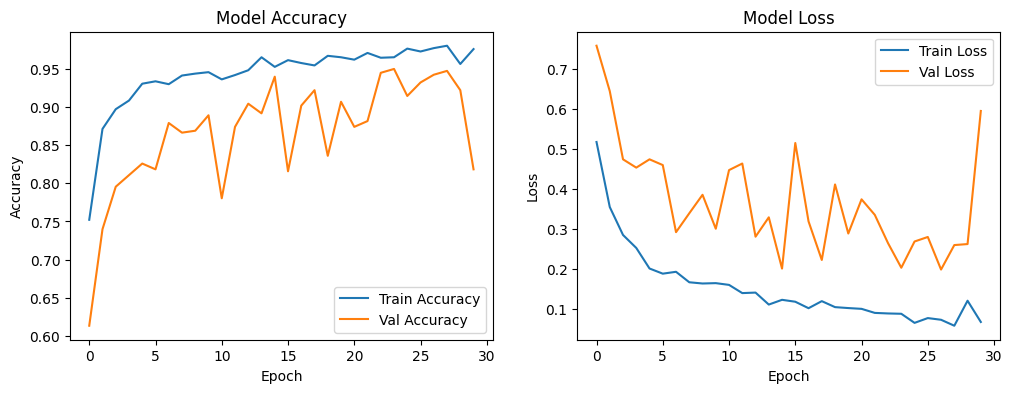

In [8]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Turn off shuffle to map predictions accurately
val_gen_no_shuffle = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
)

# Predict probabilities and map to 0/1 classes
preds = model.predict(val_gen_no_shuffle)
y_pred = (preds > 0.5).astype(int).ravel()
y_true = val_gen_no_shuffle.classes

# Print Metrics
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print(
    "\nClassification Report:\n",
    classification_report(
        y_true, y_pred, target_names=list(train_gen.class_indices.keys())
    ),
)

Found 396 images belonging to 2 classes.


c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 523ms/step
Confusion Matrix:
 [[134  61]
 [ 15 186]]

Classification Report:
               precision    recall  f1-score   support

    non_soil       0.90      0.69      0.78       195
        soil       0.75      0.93      0.83       201

    accuracy                           0.81       396
   macro avg       0.83      0.81      0.80       396
weighted avg       0.83      0.81      0.81       396



In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# Load best saved model
loaded_model = tf.keras.models.load_model("Soil_Detector.keras")


def predict_soil(image_path):
    img = image.load_img(image_path, target_size=(128, 128))
    img_array = image.img_to_array(img) / 255.0  # Rescale same as training
    img_array = np.expand_dims(img_array, axis=0)

    prediction = loaded_model.predict(img_array)[0][0]

    # Map output probability back to class names
    class_labels = {v: k for k, v in train_gen.class_indices.items()}
    predicted_class = class_labels[1 if prediction > 0.5 else 0]
    confidence = prediction if prediction > 0.5 else 1 - prediction

    print(
        f"Prediction: {predicted_class} ({confidence * 100:.2f}% confidence)"
    )


predict_soil("test_sample_2.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Prediction: soil (98.91% confidence)
